In [4]:
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import scanpy as sc
import magic

# pip install kagglehub[pandas-datasets]
import kagglehub



kagglehub.login()

In [27]:
from matplotlib.colors import ListedColormap

import matplotlib.pyplot as plt
import numpy as np
from skimage import io

### Modality Coupling

This notebook provides code for coupling cells from the Imaging modality and the Genexpression Sequencing.

We consider the cell group with PRRX1 + MYOD.

Pseudotime is performed on the cells to place them in relative order of gene expression profiles.
Bucket the expression profiles across 67 timepoints from the experiment.


## Load Computed Data

#### Genexpression data

Following code loads Precomputed genexpression data split across 67 timepoints based on pseudotime trajectories

In [21]:
adata = sc.read_h5ad('data/anndata_prrx1_myod.h5ad')

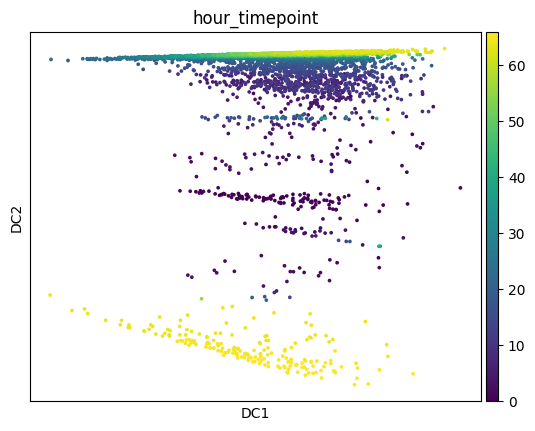

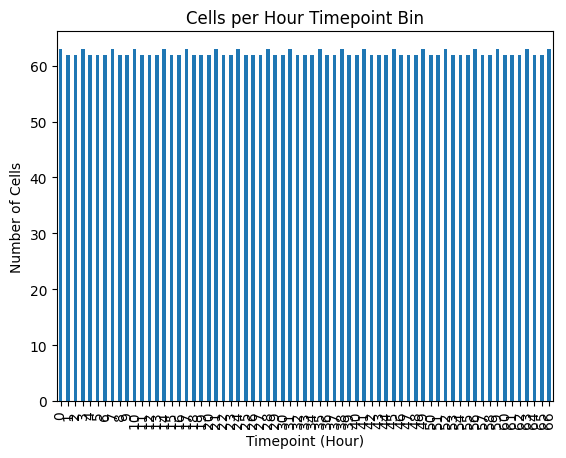

In [22]:
sc.pl.diffmap(adata, color='hour_timepoint')

adata.obs['hour_timepoint'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Timepoint (Hour)")
plt.ylabel("Number of Cells")
plt.title("Cells per Hour Timepoint Bin")
plt.show()

### Imaging data

Following code loads up Imaging data and segmentation for the cy5 channel and plots it

In [39]:
basepath = 'data/imaging'
sample = 'Myod_PRRX1'
sample_id = 1
f_start = 1
f_end = 68
channel = 'cy5'
# num_frames = 30

cmap = ListedColormap(['black', 'white'])

original_imgs = [
    io.imread(f'{basepath}/original_images/{channel}/{sample}_{sample_id}_frame_{t:03d}.tif')
    for t in range(f_start, f_end)
]

segmentation_masks = [
    io.imread(f'{basepath}/segmentation_masks/{channel}/{sample}_{sample_id}_frame_{t:03d}.tif')
    for t in range(f_start, f_end)
]

# Convert to numpy arrays
originals = np.stack(original_imgs)
segmentations = np.stack(segmentation_masks)


## Multi Modal Coupling

We can couple data based on the hour_timepoint field in the genexpression dataset and the frame number captured per hour on the imaging dataset

processing data for hour : 1


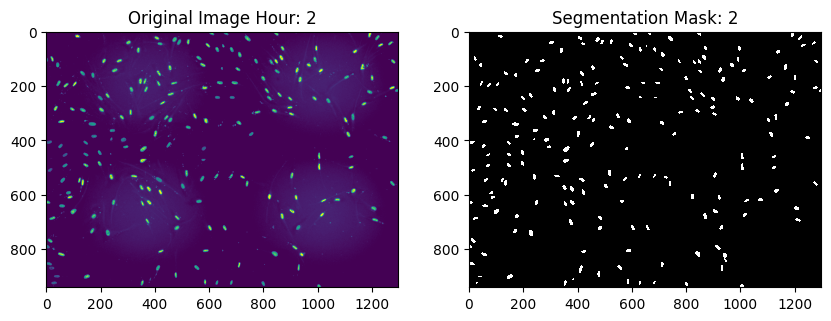

Genexpression for hour : 1 AnnData object with n_obs × n_vars = 125 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'nnz', 'dpt_pseudotime', 'hour_timepoint'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'feature_id'
    uns: 'diffmap_evals', 'iroot', 'log1p', 'neighbors', 'pca'
    obsm: 'X_diffmap', 'X_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
processing data for hour : 2


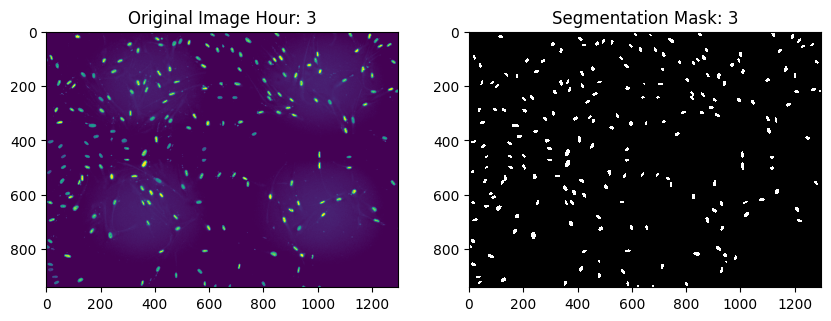

Genexpression for hour : 2 AnnData object with n_obs × n_vars = 124 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'nnz', 'dpt_pseudotime', 'hour_timepoint'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'feature_id'
    uns: 'diffmap_evals', 'iroot', 'log1p', 'neighbors', 'pca'
    obsm: 'X_diffmap', 'X_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
processing data for hour : 3


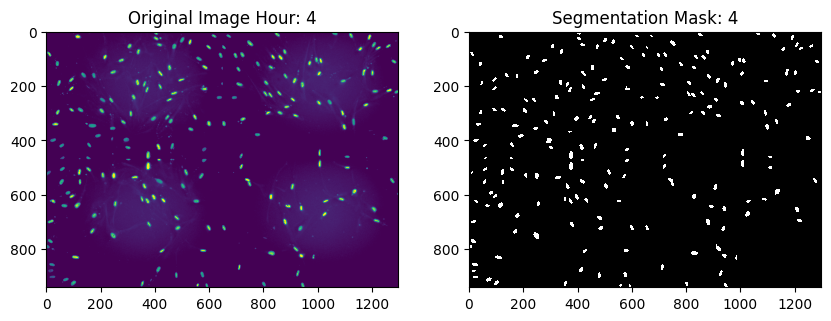

Genexpression for hour : 3 AnnData object with n_obs × n_vars = 125 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'nnz', 'dpt_pseudotime', 'hour_timepoint'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'feature_id'
    uns: 'diffmap_evals', 'iroot', 'log1p', 'neighbors', 'pca'
    obsm: 'X_diffmap', 'X_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
processing data for hour : 4


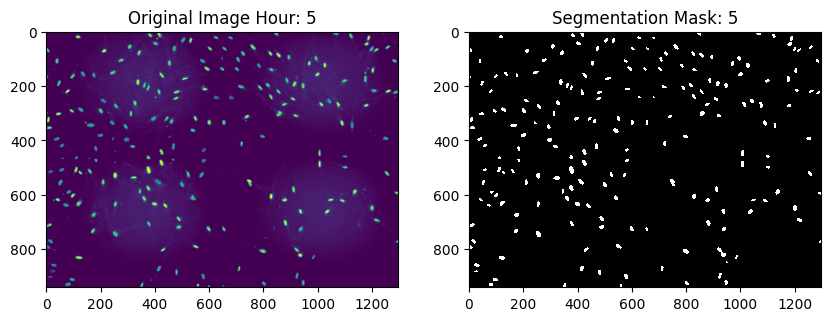

Genexpression for hour : 4 AnnData object with n_obs × n_vars = 125 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'nnz', 'dpt_pseudotime', 'hour_timepoint'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'feature_id'
    uns: 'diffmap_evals', 'iroot', 'log1p', 'neighbors', 'pca'
    obsm: 'X_diffmap', 'X_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [38]:
for i in range(f_start , 5):
    print(f'processing data for hour : {i}')
    subset = adata[(adata.obs['hour_timepoint'] >= i-1) & (adata.obs['hour_timepoint'] <= i)].copy()
    img = originals[i-1]
    mask = segmentations[i-1]
    
    full_mask = mask.copy()
    mask[mask > 1] = 1

    plt.ion()
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))
    ax1, ax2 = ax
    ax1.imshow(img)
    ax1.set_title(f'Original Image Hour: {i+1}')
    ax2.imshow(mask, cmap = cmap)
    ax2.set_title(f'Segmentation Mask: {i+1}')
    plt.show()
    
    print(f'Genexpression for hour : {i}', subset)

In [56]:
with open('/nfs/turbo/umms-indikar/Ram/development/projects/reprogramming/data/genexpression/genes.txt') as f:
    genes = [line.strip() for line in f]

In [57]:
genset = set(genes)

In [58]:
genset2 = set(list(adata.var['gene_id']))

In [ ]:
genset

In [61]:
len(genset.intersection(genset2))

16982

In [65]:
from mygene import MyGeneInfo
mg = MyGeneInfo()

genes =  list(adata.var_names) # your list
info = mg.querymany(genes, scopes='symbol', fields='type_of_gene', species='human')

coding = [g['query'] for g in info if g.get('type_of_gene') == 'protein-coding']
noncoding = [g['query'] for g in info if g.get('type_of_gene') != 'protein-coding']


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
1313 input query terms found dup hits:	[('A2ML1-AS1', 2), ('A2MP1', 2), ('AACSP1', 2), ('AADACL2-AS1', 3), ('AADACP1', 2), ('ABCC6P1', 2), 
7868 input query terms found no hit:	['ADAL', 'ARMT1', 'ATP6V1FNB', 'B3GNTL1', 'BMT2', 'BVES', 'BVES-AS1', 'C10orf82', 'C11orf80', 'C12or


In [69]:
print('coding', len(coding))
print('non coding', len(noncoding))

coding 16834
non coding 13298


## Data Generation

The following code was used to generate and store the data for the subset used in the analysis above

### Download
Download hourly data for the specific condition from Kaggle hub

In [4]:
def normalize_channel(channel):
    '''
    Normalization function that takes in a numpy channel matrix and normalizes it from 0-255
    '''
    min_, max_ = 50, 99.8
    norms = np.percentile(channel, [min_, max_])
    normal_channel = np.clip((channel - norms[0]) / (norms[1] - norms[0]), 0, 1)
    final_channel = (normal_channel * 255).astype(np.uint8)
    return final_channel


def download_condition_file_from_hyped(sample, sample_id, time_interval):
    """
    Downloads files for specific time intervals for a given condition 

    :param condition: one of four options Myod, Myod_PRRX1, PRRX1, Negative_Controls
    :type condition: string

    :param time_interval: time interval to get frames for ( in multiples of 20 minutes : 3 = 3*20 mins = 1 hour )
    :type time_interval: int
    
    
    :return: list containing downloaded condition dataset
    :rtype: list 
    """
    
    frames = []

    202 frames per sample
    for time in range(202):
        if time % time_interval == 0:
    
            file_path = '/scratch/indikar_root/indikar1/shared_data/HYB/kaggle_dataset'
            
            
            os.environ['KAGGLEHUB_CACHE']=file_path
        
            
            path=f'Imaging/Imaging/{sample}/{sample_id}/t_{time}.hdf5'
            download_path = kagglehub.dataset_download('thedoodler/hybrid-imaging-and-genex-dataset-hyb-imagen', path = path)
            print("downloaded file path : ", download_path)
        
            f = h5py.File(download_path, 'r')
            frame_shape = f['Scene'].shape
            frame = f['Scene'][:]
            frames.append(frame)

    framestack = np.stack(frames, axis=0)

    print('Downloading Genexpression data')
    gex_path = kagglehub.dataset_download('thedoodler/hybrid-imaging-and-genex-dataset-hyb-imagen', path = 'GeneExpression/Genexpression.h5ad')
    print("GEX file path : ", gex_path)

    anndata = sc.read_h5ad(gex_path)
    
    
    return framestack, anndata
    
sample = 'Myod_PRRX1'
sample_id = 1
framestack, anndata = download_condition_file_from_hyped(sample, sample_id, 3)

100%|██████████| 513M/513M [00:10<00:00, 51.1MB/s] 


GEX file path :  /home/nuvi/.cache/kagglehub/datasets/thedoodler/hybrid-imaging-and-genex-dataset-hyb-imagen/versions/3/GeneExpression/Genexpression.h5ad


### Process Genexpression

Normalize and use magic to impute data and calculate pseudotime. 
Pseudotime is bucketed into 67 time points and the h5ad object is saved.

In [ ]:
adata = anndata[anndata.obs['assigned_condition'] == 'PRRX1_MYOD']

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.diffmap(adata)

magic_operator = magic.MAGIC()
adata.X = magic_operator.fit_transform(adata.X)

# Calculate root cell based on myod expression
root_cell_index = adata.obs_vector('MYOD1').argmin()
print(root_cell_index)


adata.uns["iroot"] = root_cell_index

sc.tl.dpt(adata)

print(adata.obs['dpt_pseudotime'].head())

adata.obs['hour_timepoint'] = pd.qcut(
    adata.obs['dpt_pseudotime'],
    q=67,
    labels=np.arange(67)
).astype(int)


adata.write('data/anndata_prrx1_myod.h5ad')

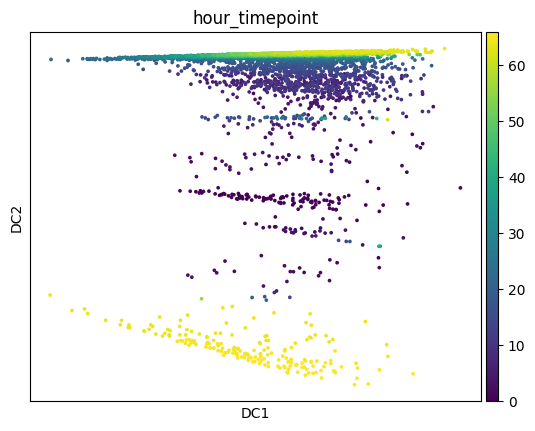

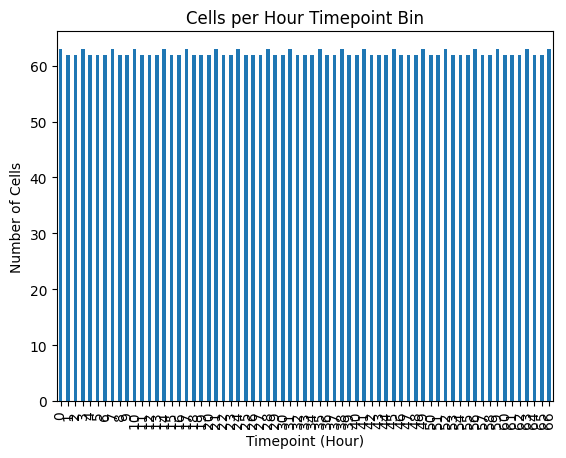

In [19]:
### Plot visualizing the buckets

adata.obs[['dpt_pseudotime', 'hour_timepoint']].to_csv("data/pseudotime_with_hour_bins.csv")

sc.pl.diffmap(adata, color='hour_timepoint')

adata.obs['hour_timepoint'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Timepoint (Hour)")
plt.ylabel("Number of Cells")
plt.title("Cells per Hour Timepoint Bin")
plt.show()

### Imaging data

Load noisemaps to reduce background noise and use the HYPED Imaging library to process all images, count cells and save the segmentation masks along with morphology to designated location 

In [ ]:
from Imaging.image_processing import *

In [ ]:
# WARNING: this piece of code outputs a lot of characters and might break browser memory


taggfp_noisemap = f'data/imaging/noise_maps/background_images_raw_TaGGFP.tif'
taggfp_noise = tifffile.imread(taggfp_noisemap)
mkate_noisemap = f'data/imaging/noise_maps/background_images_raw_mKate.tif'
mkate_noise = tifffile.imread(mkate_noisemap)
cy5_noisemap = f'data/imaging/noise_maps/background_images_raw_Cy5.tif'
cy5_noise = tifffile.imread(cy5_noisemap)


noisemap = {'TaGGFP': taggfp_noise, 'mKate': mkate_noise, 'Cy5': cy5_noise}

basepath = 'data/imaging'


cell_counts = []

timepoints, channels, shapex, shapey = framestack.shape
mapshapex, mapshapey = shapex//6, shapey//5

for t in range(1, timepoints):
    image = framestack[t][::, :mapshapex*2,:mapshapey*2]    
    nimage = plot_image(image, noisemap)
    
    
    
    frame = Frame(nimage, t, plot=False)
    
    counts = count_and_save_image(basepath, sample, sample_id, t, frame)
    
    cell_counts.append(counts)
    
# print(cell_counts)